# Introducción

# Implementación de Z-buffer desde cero

En este notebook se implementa un renderizador básico en Python para demostrar
el funcionamiento del algoritmo **Z-buffer** utilizado en gráficos 3D.

Se desarrollan las siguientes etapas:

1. Proyección de puntos 3D a 2D
2. Renderizado de triángulos sin Z-buffer
3. Implementación del Z-buffer
4. Visualización del depth buffer
5. Comparación entre ambos métodos
6. Experimentos de precisión y Z-fighting

Herramientas utilizadas:

- numpy
- matplotlib
- PIL

# Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Proyección 3D → 2D

Usamos una proyección perspectiva simple.
La coordenada (x, y, z) del mundo se transforma a (x', y') en la pantalla mediante:

x' =  x * f / (d + z) + ancho/2

y' = -y * f / (d + z) + alto/2

donde f es la distancia focal y d la distancia al observador.
El signo negativo en y es porque la imagen tiene el origen arriba a la izquierda.

In [16]:
def project(vertex, width, height, fov=256, viewer_distance=4):
    x, y, z = vertex
    factor = fov / (viewer_distance + z)
    x_proj = x * factor + width / 2
    y_proj = -y * factor + height / 2
    # Devolvemos también la profundidad original para el Z-buffer
    return (x_proj, y_proj, z)

# Definir la escena

Creamos tres triángulos que se solapan para probar la oclusión:

Triángulo rojo (lejano, z = 5)

Triángulo verde (cercano, z = 2)

Triángulo azul (profundidad variable, para observar variación en el depth buffer)

In [17]:
# Formato: cada triángulo tiene "vertices" (3x3) y "color" (R,G,B)
triangles = [
    {   # Rojo (fondo)
        "vertices": np.array([
            [-2.0, -1.0, 5.0],
            [ 2.0, -1.0, 5.0],
            [ 0.0,  2.0, 5.0]
        ]),
        "color": [1.0, 0.0, 0.0]
    },
    {   # Verde (cerca, tapa al rojo)
        "vertices": np.array([
            [-1.0, -0.5, 2.0],
            [ 1.0, -0.5, 2.0],
            [ 0.0,  1.5, 2.0]
        ]),
        "color": [0.0, 1.0, 0.0]
    },
    {   # Azul (con profundidad variable)
        "vertices": np.array([
            [-1.5, -1.2, 3.0],
            [ 1.5, -1.2, 5.0],
            [ 0.0,  1.8, 4.0]
        ]),
        "color": [0.0, 0.0, 1.0]
    }
]

width, height = 400, 400

# Renderizado sin Z-buffer (Painter's Algorithm)

Dibujamos los triángulos en el orden en que aparecen en la lista.
Si el orden es incorrecto (el triángulo lejano se dibuja después del cercano), se producirán errores de oclusión.

In [20]:
def render_no_zbuffer(triangles, order):
    """Dibuja los triángulos en el orden dado usando matplotlib.fill"""
    plt.figure(figsize=(5,5))
    for idx in order:
        tri = triangles[idx]
        # Proyectar vértices
        pts_2d = [project(v, width, height) for v in tri["vertices"]]
        xs = [p[0] for p in pts_2d]
        ys = [p[1] for p in pts_2d]
        plt.fill(xs, ys, color=tri["color"])
    plt.xlim(0, width)
    plt.ylim(height, 0)
    plt.title(f"Render sin Z-buffer (orden {order})")
    plt.axis('off')
    plt.show()

Orden correcto: primero el rojo (lejano), luego el verde (cercano). El verde tapa al rojo correctamente.

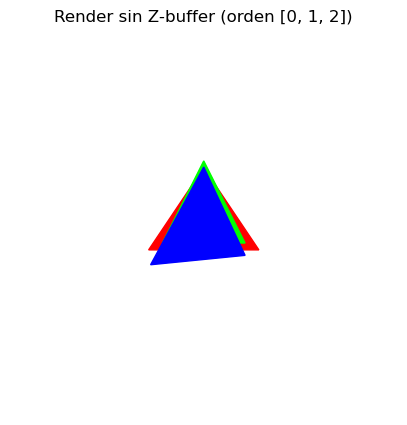

In [21]:
render_no_zbuffer(triangles, [0, 1, 2])

Orden incorrecto: primero el verde (cercano), luego el rojo (lejano). El rojo se dibuja encima del verde, produciendo un error de oclusión.

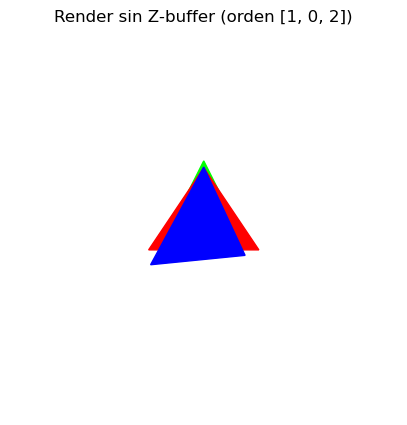

In [22]:
render_no_zbuffer(triangles, [1, 0, 2])

Observación: el painter's algorithm falla cuando los triángulos no tienen un orden de profundidad global. El Z-buffer soluciona este problema.

# Implementación del Z-buffer

Ahora rasterizamos píxel a píxel, manteniendo un buffer de profundidad.

### Inicialización

In [23]:
# Imagen en blanco (fondo negro)
image = np.zeros((height, width, 3))
# Z-buffer con valores infinitos (lejano)
zbuffer = np.full((height, width), np.inf)

### Función de rasterización con prueba de punto interior

Usamos coordenadas baricéntricas para determinar si un píxel está dentro del triángulo y para interpolar la profundidad.

In [24]:
def rasterize_triangle(v0, v1, v2, color):
    # Proyectar vértices a 2D (guardamos también la profundidad original)
    p0 = project(v0, width, height)
    p1 = project(v1, width, height)
    p2 = project(v2, width, height)
    
    x0, y0, z0 = p0
    x1, y1, z1 = p1
    x2, y2, z2 = p2
    
    # Bounding box del triángulo (recortado a la imagen)
    min_x = max(int(np.floor(min(x0, x1, x2))), 0)
    max_x = min(int(np.ceil(max(x0, x1, x2))), width-1)
    min_y = max(int(np.floor(min(y0, y1, y2))), 0)
    max_y = min(int(np.ceil(max(y0, y1, y2))), height-1)
    
    # Recorremos todos los píxeles del bounding box
    for y in range(min_y, max_y+1):
        for x in range(min_x, max_x+1):
            # Coordenadas baricéntricas
            # Usamos el método de áreas
            # Área del triángulo original
            area = 0.5 * (-(y1 - y2)*(x0 - x2) + (x1 - x2)*(y0 - y2))
            # Áreas de los sub-triángulos con el punto P
            area0 = 0.5 * (-(y1 - y2)*(x - x2) + (x1 - x2)*(y - y2))
            area1 = 0.5 * (-(y2 - y0)*(x - x0) + (x2 - x0)*(y - y0))
            area2 = 0.5 * (-(y0 - y1)*(x - x1) + (x0 - x1)*(y - y1))
            
            # Normalizamos para obtener las coordenadas baricéntricas
            if area == 0:
                continue  # triángulo degenerado
            u = area0 / area
            v = area1 / area
            w = area2 / area
            
            # El punto está dentro si 0 <= u,v,w <= 1 (tolerancia para evitar errores de precisión)
            if (u >= -1e-5 and v >= -1e-5 and w >= -1e-5 and u+v+w <= 1+1e-5):
                # Interpolar profundidad (z)
                z = u*z0 + v*z1 + w*z2
                
                # Prueba de Z-buffer
                if z < zbuffer[y, x]:
                    zbuffer[y, x] = z
                    image[y, x] = color

### Renderizar la escena con Z-buffer

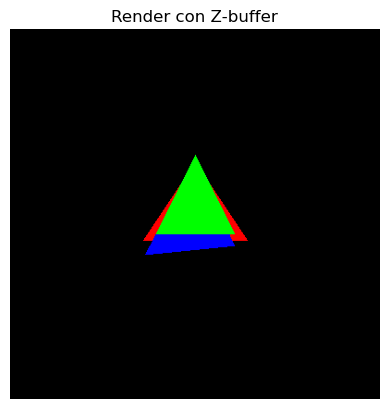

In [25]:
# Reiniciamos por si acaso
image.fill(0)
zbuffer.fill(np.inf)

for tri in triangles:
    v = tri["vertices"]
    rasterize_triangle(v[0], v[1], v[2], tri["color"])

plt.imshow(image)
plt.title("Render con Z-buffer")
plt.axis('off')
plt.show()

Ahora la oclusión es correcta independientemente del orden de dibujado.

# Visualización del Depth Buffer

Convertimos el Z-buffer en una imagen en escala de grises.

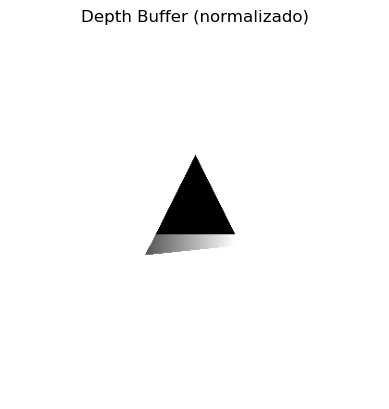

In [26]:
# Copia del zbuffer para no modificarlo
depth = zbuffer.copy()

# Reemplazar infinitos por el valor máximo finito
max_val = np.max(depth[np.isfinite(depth)])
depth[np.isinf(depth)] = max_val

# Normalizar al rango [0, 1]
depth_normalized = (depth - depth.min()) / (depth.max() - depth.min())

plt.imshow(depth_normalized, cmap='gray')
plt.title("Depth Buffer (normalizado)")
plt.axis('off')
plt.show()

Análisis: Las zonas más oscuras corresponden a los píxeles más cercanos a la cámara. El triángulo verde (cercano) se ve negro, el rojo (lejano) gris claro, y el azul muestra una variación gradual.

# Comparación lado a lado

Renderizamos la misma escena sin Z-buffer (con orden incorrecto) y con Z-buffer para contrastar.

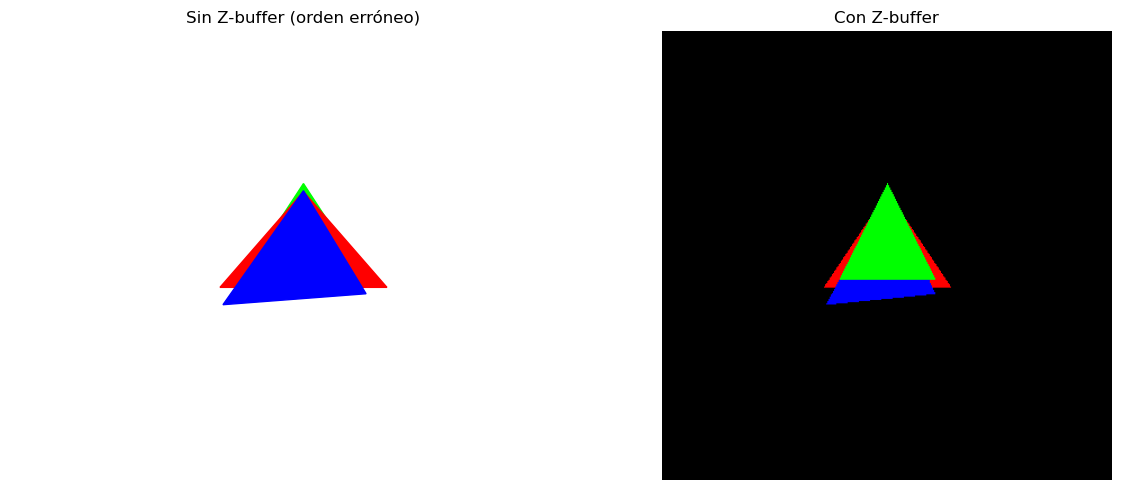

In [27]:
# Sin Z-buffer (orden incorrecto)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Sin Z-buffer: dibujamos con matplotlib en orden incorrecto
ax[0].set_xlim(0, width)
ax[0].set_ylim(height, 0)
for idx in [1, 0, 2]:  # verde, rojo, azul
    tri = triangles[idx]
    pts = [project(v, width, height) for v in tri["vertices"]]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax[0].fill(xs, ys, color=tri["color"])
ax[0].set_title("Sin Z-buffer (orden erróneo)")
ax[0].axis('off')

# Con Z-buffer
ax[1].imshow(image)
ax[1].set_title("Con Z-buffer")
ax[1].axis('off')

plt.tight_layout()
plt.show()

Se observa claramente cómo el triángulo rojo (lejano) aparece sobre el verde en la imagen izquierda, mientras que en la derecha la oclusión es correcta.

# Experimentos de precisión

### Función auxiliar para renderizar con proyección personalizada
Creamos una función que recibe la distancia al observador y la focal, y devuelve la imagen y el depth buffer locales, usando la misma lógica de rasterización con coordenadas baricéntricas (la correcta). Así evitamos interferir con las variables globales image y zbuffer.

In [30]:
def render_with_params(viewer_distance, fov):
    # Definimos la proyección local con los parámetros dados
    def project_local(v):
        x, y, z = v
        factor = fov / (viewer_distance + z)
        x_proj = x * factor + width/2
        y_proj = -y * factor + height/2
        return (x_proj, y_proj, z)
    
    # Inicializamos buffers locales
    img = np.zeros((height, width, 3))
    zb = np.full((height, width), np.inf)
    
    # Rasterizamos cada triángulo (copia de rasterize_triangle pero usando project_local y buffers locales)
    for tri in triangles:
        v = tri["vertices"]
        # Proyectamos los vértices
        p0 = project_local(v[0])
        p1 = project_local(v[1])
        p2 = project_local(v[2])
        
        x0, y0, z0 = p0
        x1, y1, z1 = p1
        x2, y2, z2 = p2
        
        # Bounding box del triángulo
        min_x = max(int(np.floor(min(x0, x1, x2))), 0)
        max_x = min(int(np.ceil(max(x0, x1, x2))), width-1)
        min_y = max(int(np.floor(min(y0, y1, y2))), 0)
        max_y = min(int(np.ceil(max(y0, y1, y2))), height-1)
        
        # Área del triángulo (para coordenadas baricéntricas)
        area = 0.5 * (-(y1 - y2)*(x0 - x2) + (x1 - x2)*(y0 - y2))
        if area == 0:
            continue  # triángulo degenerado
        
        for y in range(min_y, max_y+1):
            for x in range(min_x, max_x+1):
                # Coordenadas baricéntricas
                area0 = 0.5 * (-(y1 - y2)*(x - x2) + (x1 - x2)*(y - y2))
                area1 = 0.5 * (-(y2 - y0)*(x - x0) + (x2 - x0)*(y - y0))
                area2 = 0.5 * (-(y0 - y1)*(x - x1) + (x0 - x1)*(y - y1))
                
                u = area0 / area
                v_bar = area1 / area
                w = area2 / area
                
                if (u >= -1e-5 and v_bar >= -1e-5 and w >= -1e-5 and u+v_bar+w <= 1+1e-5):
                    # Interpolar profundidad
                    z = u*z0 + v_bar*z1 + w*z2
                    if z < zb[y, x]:
                        zb[y, x] = z
                        img[y, x] = tri["color"]
    return img, zb

### Variación del rango de profundidades (near/far)

Ahora probamos con dos distancias al observador diferentes: viewer_distance=1 (cerca) y viewer_distance=10 (lejos). Visualizamos los depth buffers normalizados de forma segura.

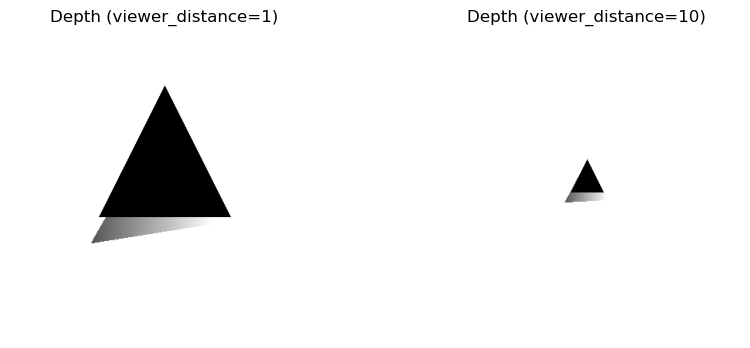

In [31]:
# Renderizar con diferentes parámetros
img_near, zb_near = render_with_params(viewer_distance=1, fov=256)
img_far,  zb_far  = render_with_params(viewer_distance=10, fov=256)

# Función para normalizar el depth buffer de manera robusta
def normalize_depth(zb):
    # Copiar para no modificar el original
    depth = zb.copy()
    # Reemplazar infinitos por el máximo valor finito
    finite_vals = depth[np.isfinite(depth)]
    if len(finite_vals) == 0:
        # Si no hay valores finitos, devolver todo ceros
        return np.zeros_like(depth)
    max_finite = np.max(finite_vals)
    depth[np.isinf(depth)] = max_finite
    # Normalizar al rango [0,1]
    depth_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-12)  # evitar división por cero
    return depth_norm

# Aplicar normalización
zb_near_norm = normalize_depth(zb_near)
zb_far_norm  = normalize_depth(zb_far)

# Mostrar
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].imshow(zb_near_norm, cmap='gray', vmin=0, vmax=1)
ax[0].set_title("Depth (viewer_distance=1)")
ax[0].axis('off')
ax[1].imshow(zb_far_norm, cmap='gray', vmin=0, vmax=1)
ax[1].set_title("Depth (viewer_distance=10)")
ax[1].axis('off')
plt.show()

Observación:

Con el observador más cerca (viewer_distance=1), los objetos ocupan un rango más amplio de profundidades relativas, lo que suele dar mejor precisión en el Z-buffer.

Con el observador más lejos (viewer_distance=10), las diferencias de profundidad se comprimen, lo que puede provocar pérdida de precisión y aumentar la probabilidad de Z-fighting.

### Simulación de Z-fighting

Creamos dos triángulos casi idénticos en profundidad (difieren en 0.001 unidades) para observar el efecto de "parpadeo" o mezcla de colores debido a la precisión finita del Z-buffer.

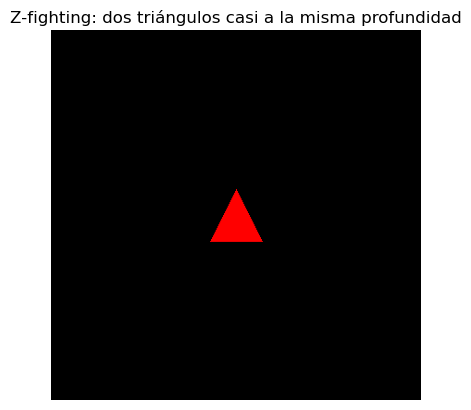

In [32]:
# Definimos dos triángulos rojo y verde con Z muy cercanas
zf_tri1 = {
    "vertices": np.array([[-1, -1, 5.0], [1, -1, 5.0], [0, 1, 5.0]]),
    "color": [1, 0, 0]  # rojo
}
zf_tri2 = {
    "vertices": np.array([[-1, -1, 5.001], [1, -1, 5.001], [0, 1, 5.001]]),
    "color": [0, 1, 0]  # verde
}

# Renderizamos con la proyección estándar (podemos usar la función project global)
# pero usando buffers locales para no afectar el resto
img_zf = np.zeros((height, width, 3))
zb_zf = np.full((height, width), np.inf)

# Rasterizamos los dos triángulos (podemos reutilizar el código de rasterize_triangle adaptado a buffers locales)
def rasterize_tri_local(v0, v1, v2, color, img, zb):
    # Proyectar con la función global project (o podemos usar la misma de antes)
    p0 = project(v0, width, height)
    p1 = project(v1, width, height)
    p2 = project(v2, width, height)
    x0, y0, z0 = p0
    x1, y1, z1 = p1
    x2, y2, z2 = p2
    
    # Bounding box
    min_x = max(int(np.floor(min(x0, x1, x2))), 0)
    max_x = min(int(np.ceil(max(x0, x1, x2))), width-1)
    min_y = max(int(np.floor(min(y0, y1, y2))), 0)
    max_y = min(int(np.ceil(max(y0, y1, y2))), height-1)
    
    area = 0.5 * (-(y1 - y2)*(x0 - x2) + (x1 - x2)*(y0 - y2))
    if area == 0:
        return
    
    for y in range(min_y, max_y+1):
        for x in range(min_x, max_x+1):
            area0 = 0.5 * (-(y1 - y2)*(x - x2) + (x1 - x2)*(y - y2))
            area1 = 0.5 * (-(y2 - y0)*(x - x0) + (x2 - x0)*(y - y0))
            area2 = 0.5 * (-(y0 - y1)*(x - x1) + (x0 - x1)*(y - y1))
            u = area0 / area
            v_ = area1 / area
            w = area2 / area
            if (u >= -1e-5 and v_ >= -1e-5 and w >= -1e-5 and u+v_+w <= 1+1e-5):
                z = u*z0 + v_*z1 + w*z2
                if z < zb[y, x]:
                    zb[y, x] = z
                    img[y, x] = color

# Dibujamos ambos triángulos
rasterize_tri_local(zf_tri1["vertices"][0], zf_tri1["vertices"][1], zf_tri1["vertices"][2], zf_tri1["color"], img_zf, zb_zf)
rasterize_tri_local(zf_tri2["vertices"][0], zf_tri2["vertices"][1], zf_tri2["vertices"][2], zf_tri2["color"], img_zf, zb_zf)

plt.imshow(img_zf)
plt.title("Z-fighting: dos triángulos casi a la misma profundidad")
plt.axis('off')
plt.show()

Aparece píxeles de color rojo y verde entremezclados, porque el orden de dibujado y las pequeñas diferencias de profundidad hacen que a veces gane uno u otro debido a la precisión limitada de los números de punto flotante. Este fenómeno se conoce como Z-fighting.

### Guardar imágenes con PIL
Finalmente, guardamos el render con Z-buffer como archivo PNG.

In [33]:
# Convertir imagen de float [0,1] a uint8 [0,255]
img_uint8 = (image * 255).astype(np.uint8)
Image.fromarray(img_uint8).save("render_zbuffer.png")

# También guardamos el depth buffer
depth_uint8 = (depth_normalized * 255).astype(np.uint8)
Image.fromarray(depth_uint8).save("depth_buffer.png")

# Conclusiones
* El painter's algorithm es sencillo pero falla cuando los objetos se solapan sin un orden global de profundidad.

* El Z-buffer resuelve el problema almacenando la profundidad por píxel y actualizando solo cuando el nuevo fragmento es más cercano.

* La precisión del Z-buffer depende de la distancia al observador y del rango de profundidades; cerca del límite pueden aparecer artefactos como Z-fighting.

* La visualización del depth buffer permite analizar la distribución de profundidades en la escena.